## 04 · Prophet Baseline

**Goals**
1. Aggregate all stores/departments into total weekly sales.
2. Train a **Prophet** model with yearly seasonality and custom holiday effects.
3. Plot the forecast with uncertainty intervals.
4. Plot decomposed trend + seasonality components.
5. Evaluate on the validation and test sets.
6. Save the trained model for later comparison.

---
Prophet is used as the **time-series baseline** for comparison against tree-based models.

> **Install**: `pip install prophet`

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.data_loader  import load_raw_data, merge_datasets, get_aggregated_weekly
from src.models       import calc_metrics
from src.config       import (TRAIN_END_DATE, VAL_END_DATE,
                               PROPHET_FILE, PRIMARY_COLOR, SECONDARY_COLOR)

plt.rcParams["figure.dpi"] = 110

try:
    from prophet import Prophet
    print("Prophet imported OK")
except ImportError:
    print("Prophet not found — run: pip install prophet")

Importing plotly failed. Interactive plots will not work.


Prophet imported OK


---
## 1 · Load & Aggregate

In [2]:
train_df, features_df, stores_df = load_raw_data()
df = merge_datasets(train_df, features_df, stores_df)
weekly = get_aggregated_weekly(df)

print("\nProphet input format [ds, y]:")
display(weekly.head())
print(f"\nDate range: {weekly['ds'].min().date()} → {weekly['ds'].max().date()}")
print(f"Total periods: {len(weekly)}")

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols
Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26
Weekly aggregation: 143 time periods

Prophet input format [ds, y]:


,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30



Date range: 2010-02-05 → 2012-10-26
Total periods: 143


---
## 2 · Train / Val / Test Split for Prophet

In [3]:
split_train = pd.Timestamp(TRAIN_END_DATE)
split_val   = pd.Timestamp(VAL_END_DATE)

prophet_train = weekly[weekly["ds"] < split_train].reset_index(drop=True)
prophet_val   = weekly[(weekly["ds"] >= split_train) & (weekly["ds"] < split_val)].reset_index(drop=True)
prophet_test  = weekly[weekly["ds"] >= split_val].reset_index(drop=True)

print(f"Train: {len(prophet_train)} weeks  ({prophet_train['ds'].min().date()} – {prophet_train['ds'].max().date()})")
print(f"Val  : {len(prophet_val)} weeks  ({prophet_val['ds'].min().date()} – {prophet_val['ds'].max().date()})")
print(f"Test : {len(prophet_test)} weeks  ({prophet_test['ds'].min().date()} – {prophet_test['ds'].max().date()})")

Train: 121 weeks  (2010-02-05 – 2012-05-25)
Val  : 9 weeks  (2012-06-01 – 2012-07-27)
Test : 13 weeks  (2012-08-03 – 2012-10-26)


---
## 3 · Define Custom Holidays

In [4]:
black_friday = pd.DataFrame({
    "holiday":      "black_friday",
    "ds":           pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23"]),
    "lower_window": -1,
    "upper_window":  2,
})

thanksgiving = pd.DataFrame({
    "holiday":      "thanksgiving",
    "ds":           pd.to_datetime(["2010-11-25", "2011-11-24", "2012-11-22"]),
    "lower_window": 0,
    "upper_window": 0,
})

christmas = pd.DataFrame({
    "holiday":      "christmas",
    "ds":           pd.to_datetime(["2010-12-24", "2011-12-24", "2012-12-24"]),
    "lower_window": -3,
    "upper_window":  1,
})

super_bowl = pd.DataFrame({
    "holiday":      "super_bowl",
    "ds":           pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10"]),
    "lower_window": -1,
    "upper_window":  1,
})

holidays = pd.concat([black_friday, thanksgiving, christmas, super_bowl],
                     ignore_index=True)
print(f"Defined {len(holidays)} holiday rows across {holidays['holiday'].nunique()} events")
print(holidays.to_string(index=False))

Defined 12 holiday rows across 4 events
     holiday         ds  lower_window  upper_window
black_friday 2010-11-26            -1             2
black_friday 2011-11-25            -1             2
black_friday 2012-11-23            -1             2
thanksgiving 2010-11-25             0             0
thanksgiving 2011-11-24             0             0
thanksgiving 2012-11-22             0             0
   christmas 2010-12-24            -3             1
   christmas 2011-12-24            -3             1
   christmas 2012-12-24            -3             1
  super_bowl 2010-02-12            -1             1
  super_bowl 2011-02-11            -1             1
  super_bowl 2012-02-10            -1             1


---
## 4 · Train Prophet

In [5]:
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10.0,
    n_changepoints=25,
)

print("Training Prophet...")
prophet.fit(prophet_train)
print("Training complete. ✓")

14:56:29 - cmdstanpy - INFO - Chain [1] start processing
14:56:29 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet...
Training complete. ✓


---
## 5 · Forecast Plot

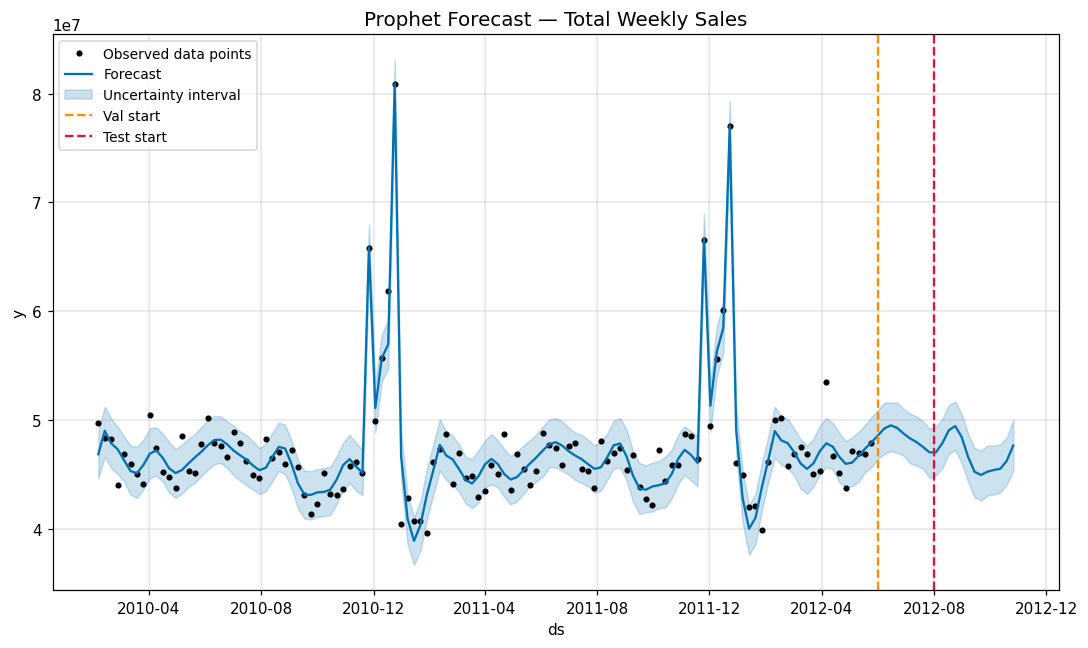

In [6]:
# Build future dataframe covering train + val + test
future = pd.concat([
    prophet_train[["ds"]],
    prophet_val[["ds"]],
    prophet_test[["ds"]],
], ignore_index=True)

forecast = prophet.predict(future)

fig = prophet.plot(forecast)
plt.axvline(split_train, color="darkorange", linestyle="--", linewidth=1.5,
            label="Val start")
plt.axvline(split_val, color="crimson", linestyle="--", linewidth=1.5,
            label="Test start")
plt.title("Prophet Forecast — Total Weekly Sales", fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6 · Component Decomposition

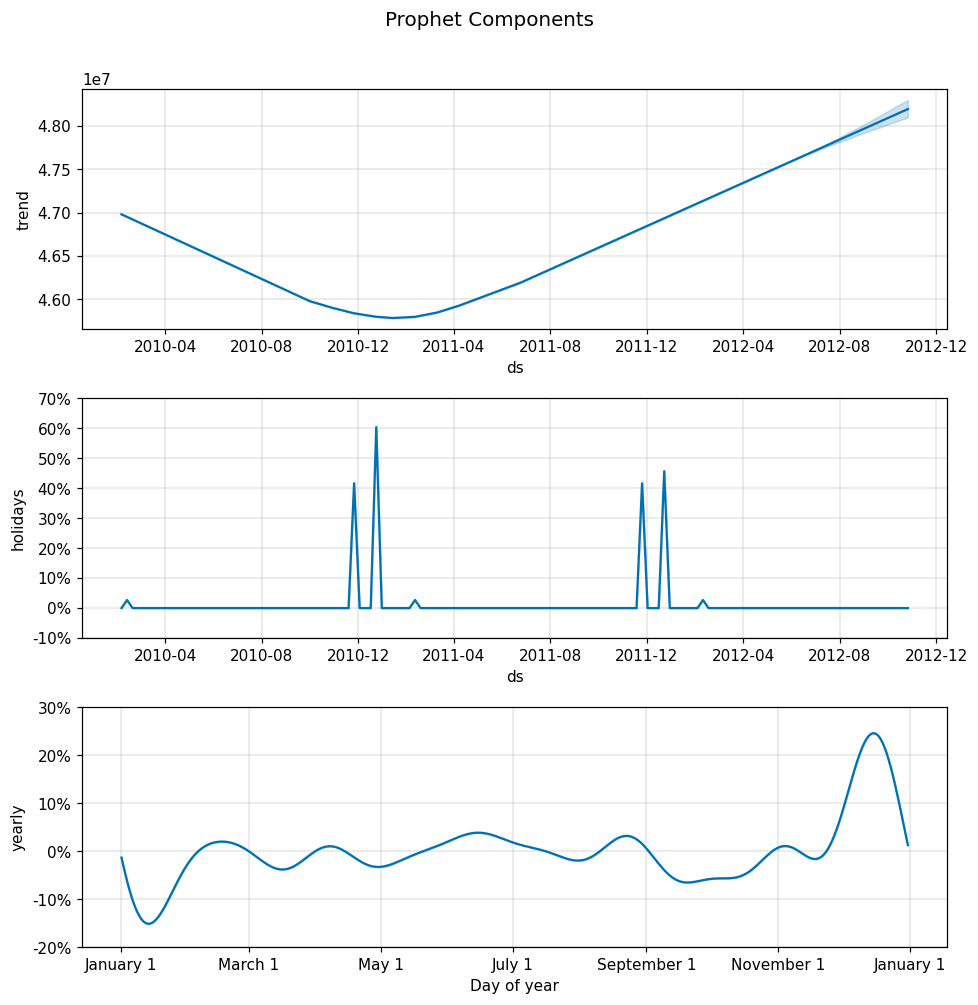

In [7]:
fig = prophet.plot_components(forecast)
plt.suptitle("Prophet Components", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7 · Evaluation

In [8]:
def predict_set(model, df_set):
    """Predict and align to the original dates."""
    fc = model.predict(df_set[["ds"]])
    return fc["yhat"].values

train_pred = predict_set(prophet, prophet_train)
val_pred   = predict_set(prophet, prophet_val)
test_pred  = predict_set(prophet, prophet_test)

metrics_rows = [
    calc_metrics(prophet_train["y"], train_pred, "Train"),
    calc_metrics(prophet_val["y"],   val_pred,   "Val"),
    calc_metrics(prophet_test["y"],  test_pred,  "Test"),
]
metrics_df = pd.DataFrame(metrics_rows)

print("Prophet — Aggregated Weekly Sales")
print("=" * 55)
print(metrics_df.to_string(index=False, float_format="%.4f"))

Prophet — Aggregated Weekly Sales
  Set         RMSE          MAE     R2  MAPE(%)
Train 1752374.9272 1326408.9185 0.9101   2.8736
  Val 1865155.5825 1634145.1198 0.1439   3.4638
 Test 1417660.0061 1282069.9386 0.0725   2.7630


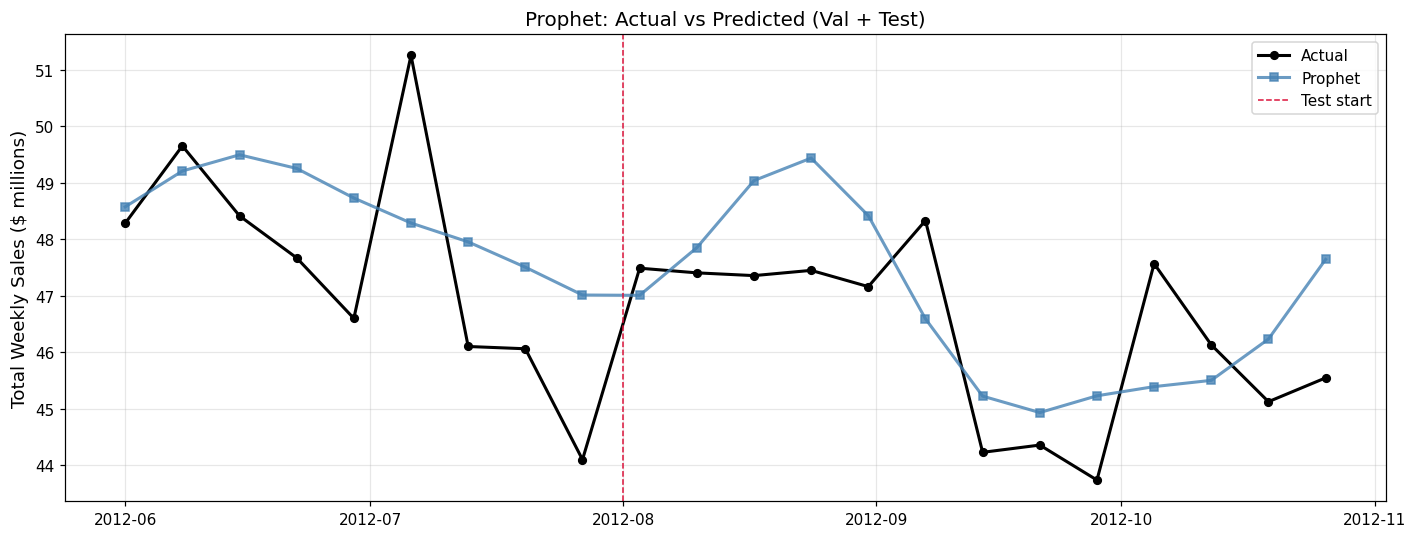

In [9]:
# Actual vs Predicted on val + test
combined = pd.concat([prophet_val, prophet_test], ignore_index=True)
combined_pred = np.concatenate([val_pred, test_pred])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(combined["ds"], combined["y"] / 1e6,
        label="Actual", color="black", linewidth=2, marker="o", markersize=5)
ax.plot(combined["ds"], combined_pred / 1e6,
        label="Prophet", color=PRIMARY_COLOR, linewidth=2, marker="s", markersize=5, alpha=0.8)
ax.axvline(split_val, color="crimson", linestyle="--", linewidth=1, label="Test start")
ax.set_title("Prophet: Actual vs Predicted (Val + Test)", fontsize=13)
ax.set_ylabel("Total Weekly Sales ($ millions)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8 · Save Model

In [10]:
import pickle, os

os.makedirs(os.path.dirname(PROPHET_FILE), exist_ok=True)

with open(PROPHET_FILE, "wb") as f:
    pickle.dump(prophet, f)

print(f"Model saved: {PROPHET_FILE}")

# Store metrics for comparison in notebook 06
prophet_val_metrics  = calc_metrics(prophet_val["y"],  val_pred,  "Prophet-Val")
prophet_test_metrics = calc_metrics(prophet_test["y"], test_pred, "Prophet-Test")
print("\nVal RMSE  :", f"${prophet_val_metrics['RMSE']:,.0f}")
print("Test RMSE :", f"${prophet_test_metrics['RMSE']:,.0f}")
print("Test R²   :", f"{prophet_test_metrics['R2']:.4f}")

Model saved: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/prophet_model.pkl

Val RMSE  : $1,865,156
Test RMSE : $1,417,660
Test R²   : 0.0725


---
## Summary

### Prophet Results — Aggregated Weekly Sales (all 45 stores)

| Set | Periods | RMSE | MAE | R² | MAPE |
|-----|---------|------|-----|----|------|
| Train | 121 | $1,752,375 | $1,326,409 | 0.9101 | 2.87% |
| Val | 9 | $1,865,156 | $1,634,145 | 0.1439 | 3.46% |
| Test | 13 | $1,417,660 | $1,282,070 | 0.0725 | 2.76% |

### Why Val / Test R² Is So Low

Prophet's R² drops from 0.91 on train to 0.07 on test. This is not overfitting — it is a
**small-sample effect**: the entire validation set is only 9 data points and the test set is
only 13 weekly totals. R² at this granularity is highly sensitive to a few large fluctuations.
The MAPE (≈2.8%) is more representative: Prophet predicts aggregate weekly sales to within ~3%.

The real limitation is **granularity**: Prophet is trained on 143 total weekly sums with no
store or department context. It correctly captures the yearly seasonality shape but cannot model
individual store-dept behaviour — which is where XGBoost/LightGBM excel.

### Key Findings

- Prophet correctly identifies the **Thanksgiving / Black Friday spike** in the yearly component.
- The **trend component** is nearly flat, confirming the stable pattern seen in Notebook 01.
- The **Super Bowl week** shows a small but detectable dip (fewer shopping trips during game week).
- Prophet is best suited for **executive-level total-sales reporting**, not per-dept forecasting.

**Next**: `05_xgboost_lgbm.ipynb` — XGBoost and LightGBM with time-aware validation on 197k rows.